## ISSW_Compare_Spectra

Here we're just looking at a couple of spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from importlib import reload  # Python 3.4+
import ISSWlib as IS; reload(IS)
import pandas as pd
import os
%matplotlib inline

In [2]:
parameter_filename = 'calibration IV parameters (nucleopore) (July 22, 2026).csv'

df = pd.read_csv(parameter_filename)
print(df)
calibration_spectrum_folder = df.at[0, 'calibration_spectrum_folder']
betabar_450_std = df.at[0,'betabar_450_std']
betabar_600_std = df.at[0,'betabar_600_std']
filtertype_std = df.at[0,'filtertype_std']
p_L_450 = df.at[0,'p_L_450'],
p_L_600 = df.at[0,'p_L_600'],
AAE_std = df.at[0,'AAE_std']

p_L_450 = p_L_450[0]; print(p_L_450)
p_L_600 = p_L_600[0]; print(p_L_600)
p_L_450 = np.fromstring(p_L_450[1:-1], dtype=float, sep=' '); print(p_L_450)
p_L_600 = np.fromstring(p_L_600[1:-1], dtype=float, sep=' '); print(p_L_600)

  calibration_spectrum_folder  betabar_450_std  betabar_600_std  \
0           UPS_INKStandards/         0.062232         0.054982   

  filtertype_std                                            p_L_450  \
0     nucleopore  [ 6.25586230e+00  6.23233270e+00 -2.04196145e-05]   

                                             p_L_600   AAE_std  
0  [ 5.40369813e+00  7.86488659e+00 -6.66150850e-06]  0.430525  
[ 6.25586230e+00  6.23233270e+00 -2.04196145e-05]
[ 5.40369813e+00  7.86488659e+00 -6.66150850e-06]
[ 6.25586230e+00  6.23233270e+00 -2.04196145e-05]
[ 5.40369813e+00  7.86488659e+00 -6.66150850e-06]


['C.57mL.txt', '28mL.txt', '.ipynb_checkpoints', 'A.14mL.txt', 'Blank.txt', 'C.20mL.txt', 'C.50mL.txt', 'B.10mL.txt', 'spectrum_files_with_loading.txt', 'spectrum_files.txt', 'C.34mL.txt']
From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt
extracting UPS_INKStandards/ B.10mL.txt
['C.57mL.txt', '28mL.txt', '.ipynb_checkpoints', 'A.14mL.txt', 'Blank.txt', 'C.20mL.txt', 'C.50mL.txt', 'B.10mL.txt', 'spectrum_files_with_loading.txt', 'spectrum_files.txt', 'C.34mL.txt']
From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt
extracting UPS_INKStandards/ A.14mL.txt
['C.57mL.txt', '28mL.txt', '.ipynb_checkpoints', 'A.14mL.txt', 'Blank.txt', 'C.20mL.txt', 'C.50mL.txt', 'B.10mL.txt', 'spectrum_files_with_loading.txt', 'spectrum_files.t

/home/chemistry/LAI_in_snow/ISSW/ISSWlib.py:136: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


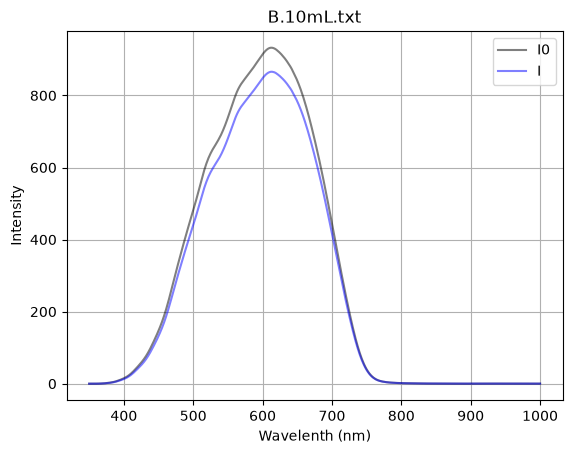

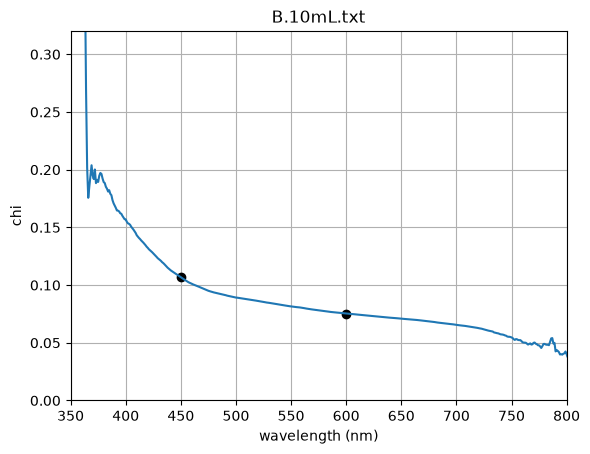

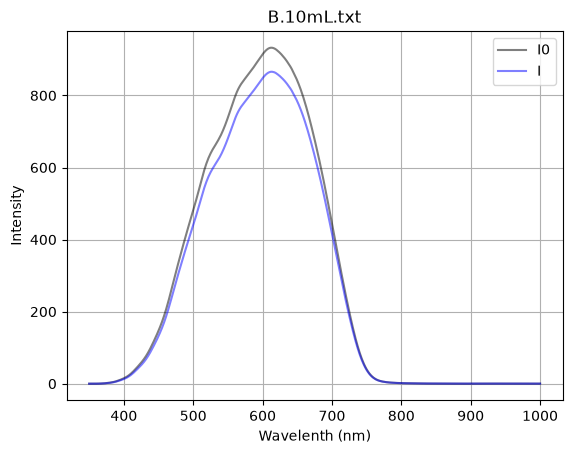

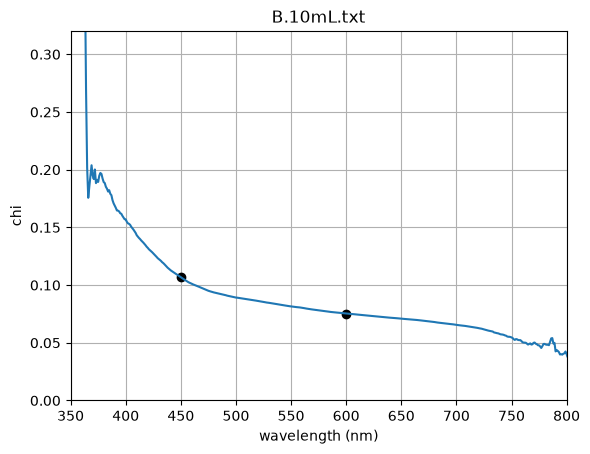

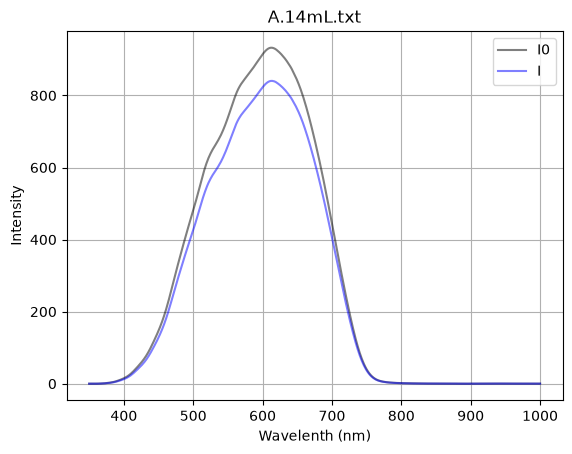

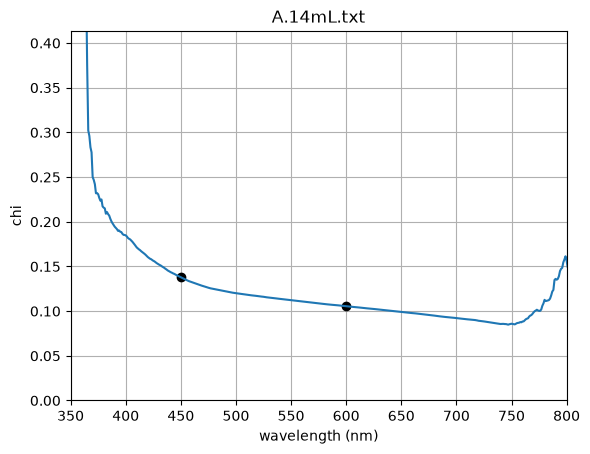

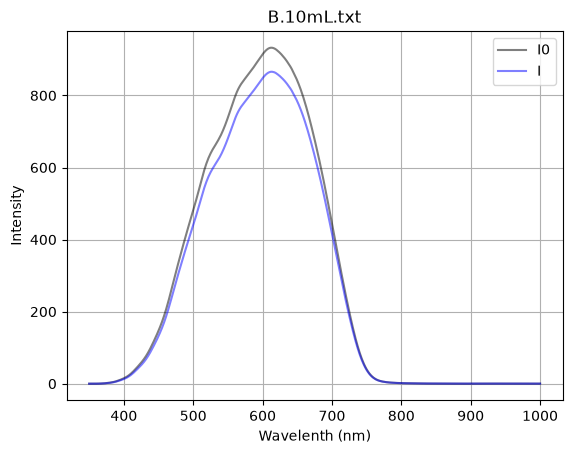

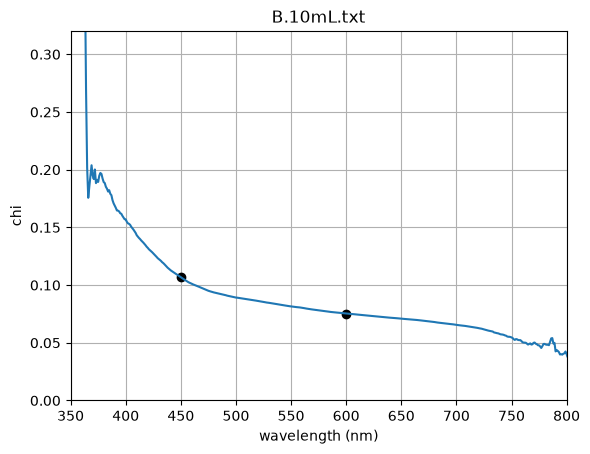

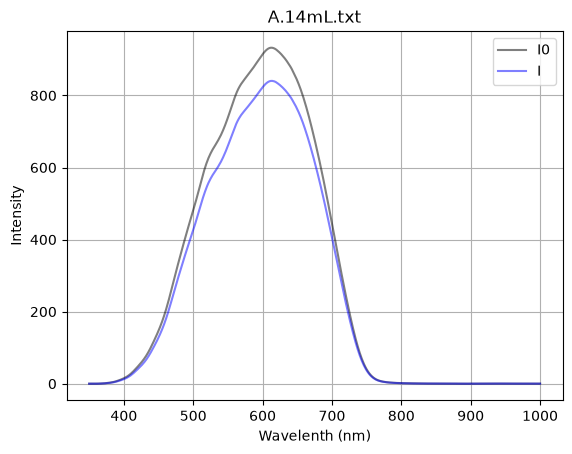

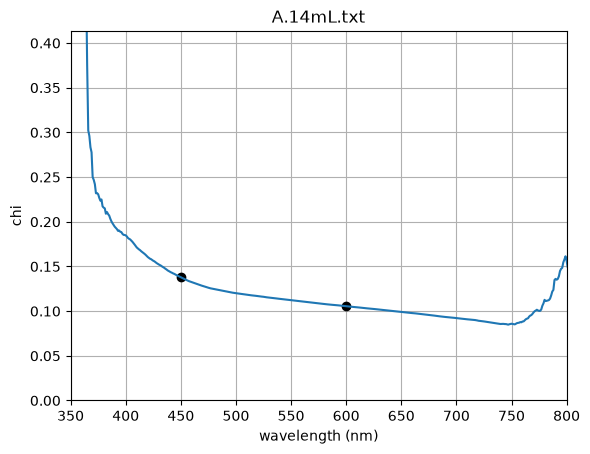

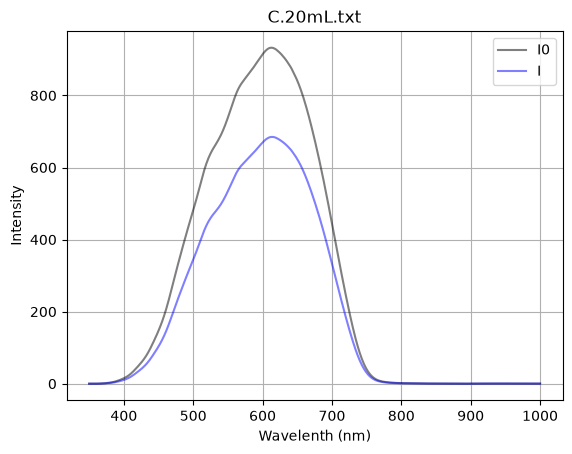

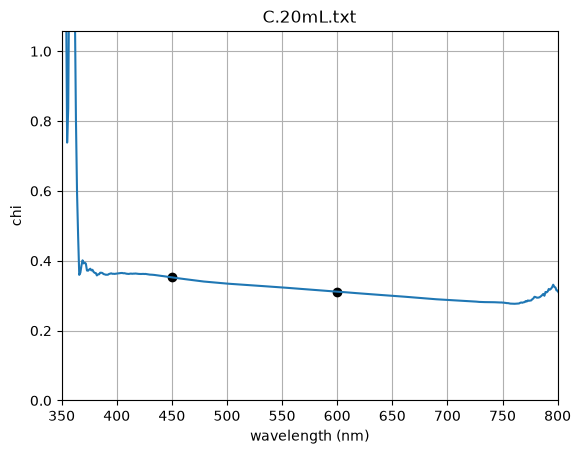

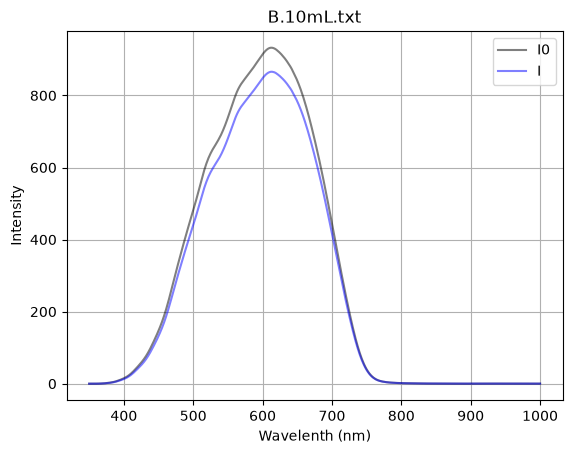

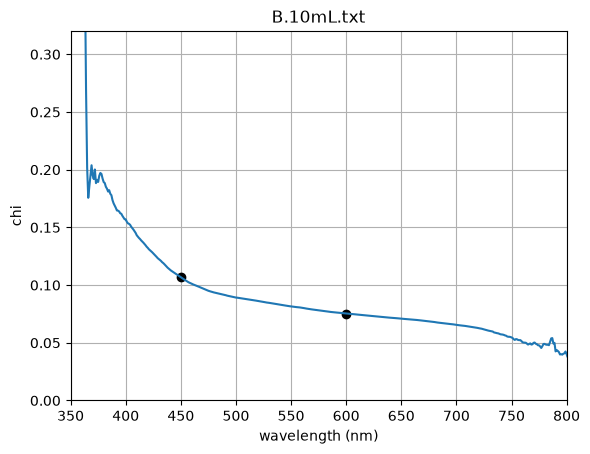

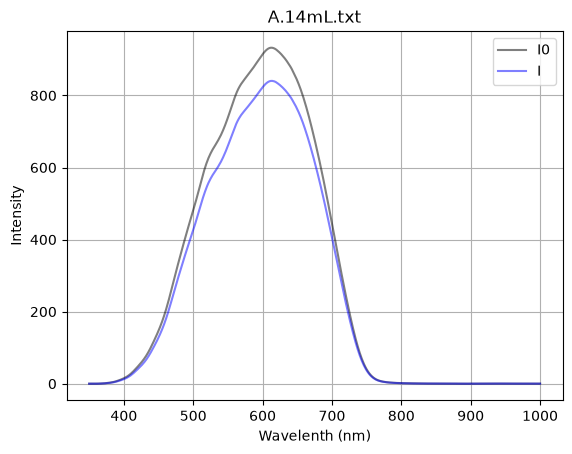

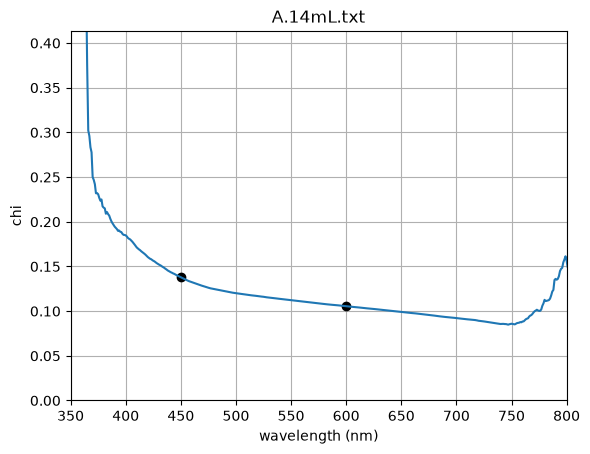

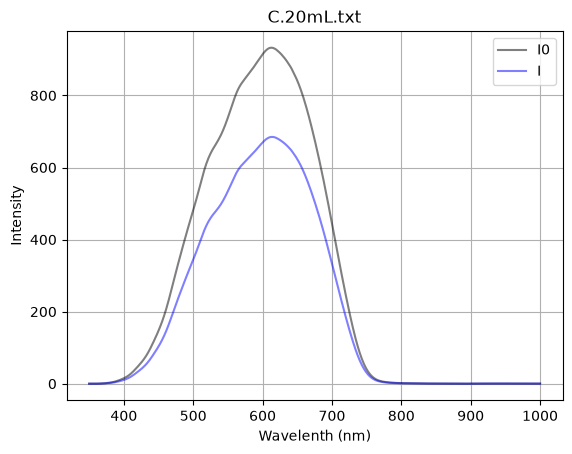

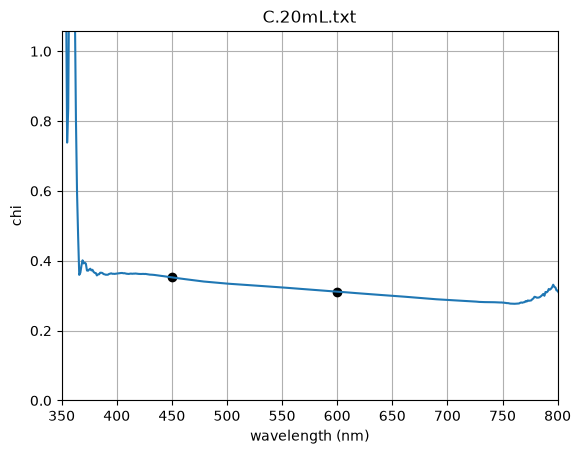

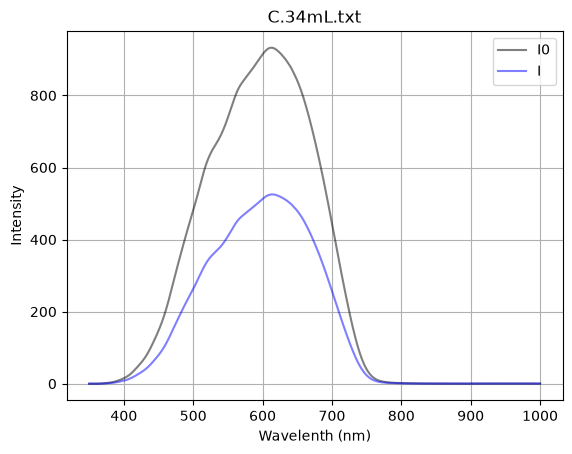

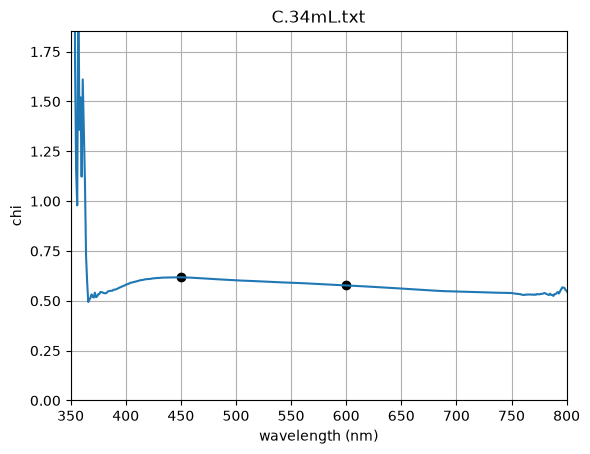

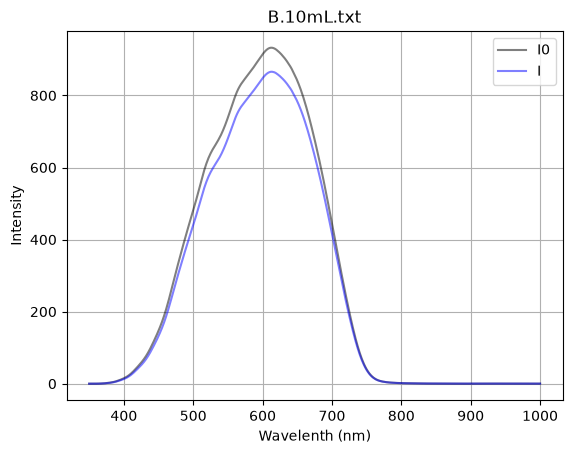

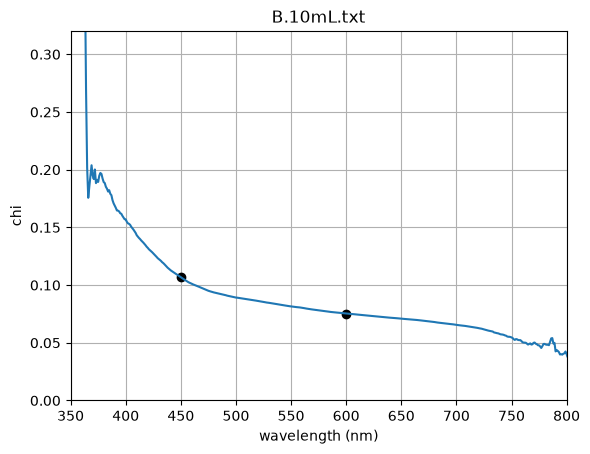

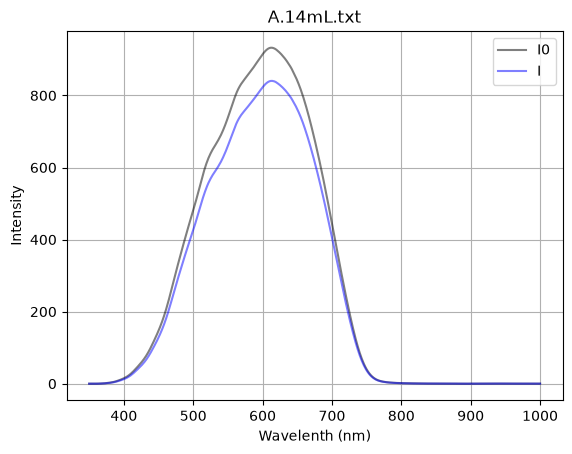

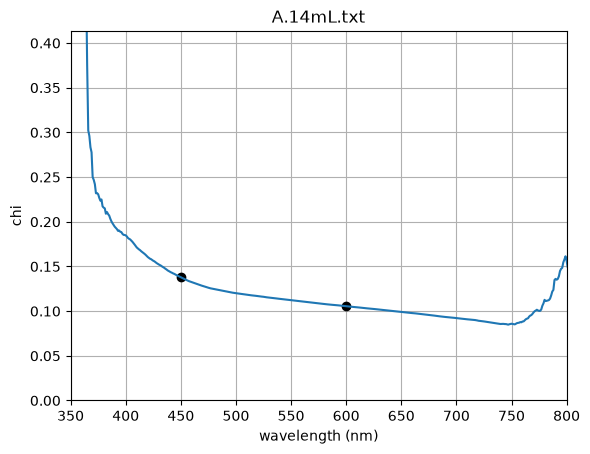

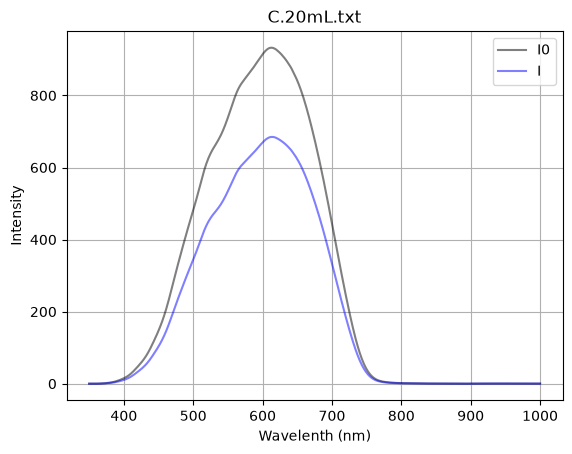

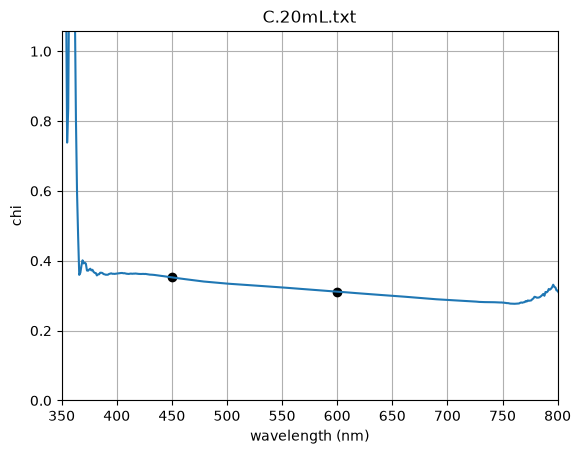

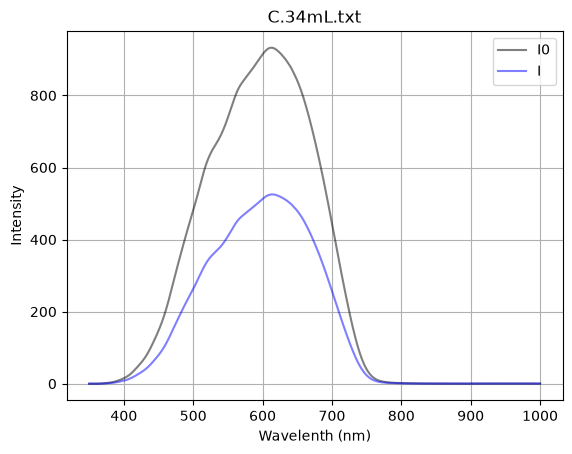

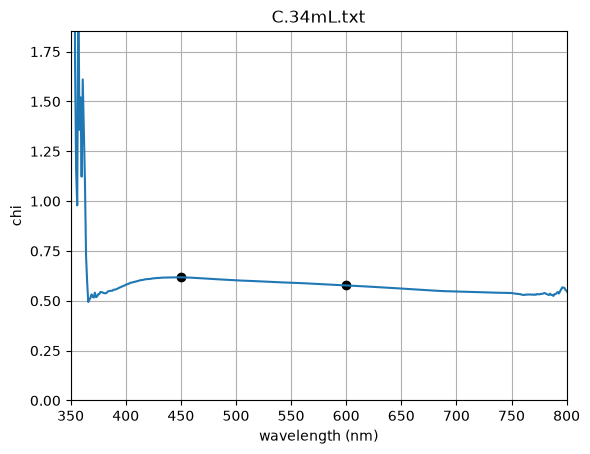

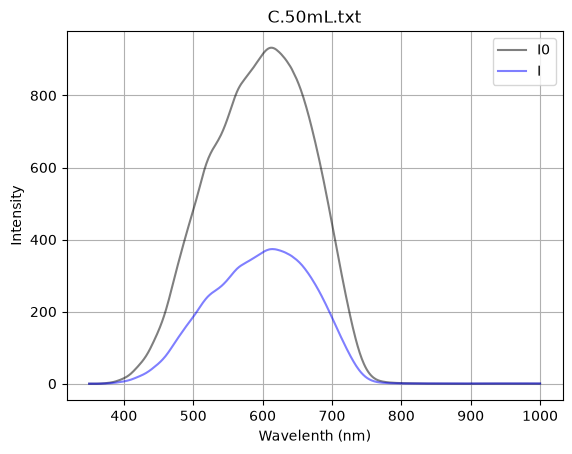

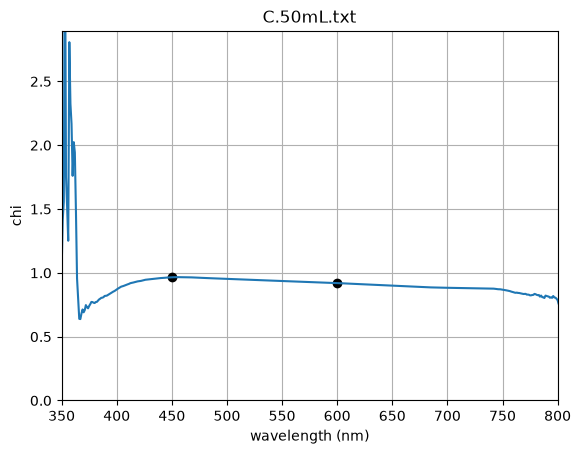

In [3]:
# Choose the spectrum folder and load in the list of spectra there
# spectrum_folder = 'Rainier_and_MtCook_comparison/'
# spectrum_folder = 'UPS_Rainier2025-07-03-01/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Adams_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Misc_1/'; filtertype = 'millipore'
# spectrum_folder = 'Ulyana ful/'; filtertype = 'millipore'
# spectrum_folder = 'Ponderosa pine pollen/'; filtertype = 'millipore'
# spectrum_folder = 'Rainier dirt/'; filtertype = 'millipore'

# spectrum_folder = 'UPS_2016Chile/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'
# spectrum_folder = 'UPS_INKStandards/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucInc/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucFul/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'

# spectrum_list = \
# [
#     ['UPS_Rainier2025-07-03-01/',   0],
#     ['UPS_Rainier2025-07-03-01/',   6],
#     ['Ponderosa pine pollen/',   2],
#     ['Ulyana ful/', 2],
#     ['UPS_INKStandards/', 3]
# ]
spectrum_list = \
[
    ['UPS_INKStandards/', 0],
    ['UPS_INKStandards/', 1],
    ['UPS_INKStandards/', 2],
    ['UPS_INKStandards/', 3],
    ['UPS_INKStandards/', 4]
]
number_of_loadings = len(spectrum_list)

I_450 = 100; #print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; #print('lambda_600 = ',lambda_nm[I_600])

chi_list = []
chi_normalized_list = []
chi600_list = []

taubar_list = []
taubar_normalized_list = []
tau600_list = []

spectrum_name_list = []

for i in range(number_of_loadings):
    lambda_nm, chi, spectrum_name = IS.extract_chi_spectrum(spectrum_list[i][0],spectrum_list[i][1])
    taubar = betabar_450_std*np.polyval(p_L_450,chi)
    
    chi_list.append(chi)
    chi_normalized = chi/chi[I_450]
    chi_normalized_list.append(chi_normalized)
    chi600_list.append(chi_normalized[I_600])
    
    taubar_list.append(taubar)
    taubar_normalized = taubar/taubar[I_450]
    taubar_normalized_list.append(taubar_normalized)
    tau600_list.append(taubar_normalized[I_600])
    
    spectrum_name_list.append(spectrum_name)

    


[4 3 2 1 0]
working on  0 4
working on  1 3
working on  2 2
working on  3 1
working on  4 0


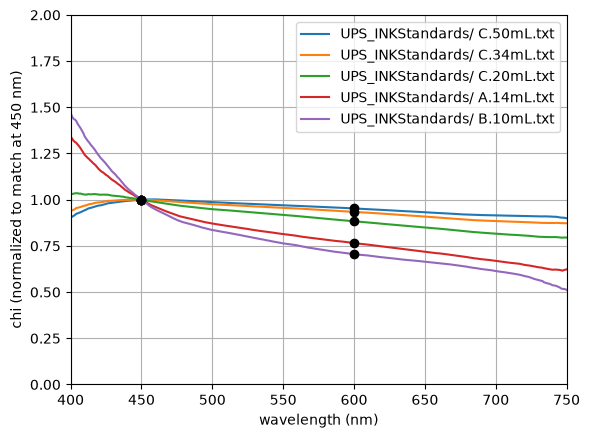

In [4]:
i_in_descending_order = np.argsort(chi600_list,descending=True)
print(i_in_descending_order)

plt.figure()
for ispec in range(len(spectrum_list)):
    i = i_in_descending_order[ispec]
    print('working on ', ispec, i)
    chi_normalized = chi_normalized_list[i]
    plt.plot(lambda_nm,chi_normalized,label=spectrum_name_list[i])
    plt.plot(lambda_nm[I_450],chi_normalized[I_450],'ko')
    plt.plot(lambda_nm[I_600],chi_normalized[I_600],'ko')

plt.xlabel('wavelength (nm)')
plt.ylabel('chi (normalized to match at 450 nm)')
plt.xlim([400,750])
plt.ylim([0,2])
plt.grid(True)
plt.legend()

[4 3 2 1 0]
working on  0 4
working on  1 3
working on  2 2
working on  3 1
working on  4 0


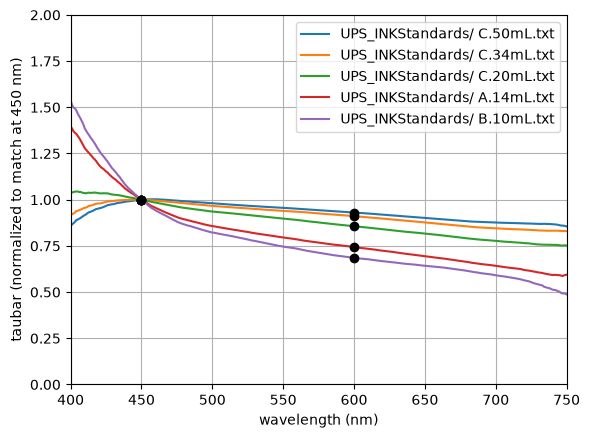

In [5]:
i_in_descending_order = np.argsort(tau600_list,descending=True)
print(i_in_descending_order)

plt.figure()
for ispec in range(len(spectrum_list)):
    i = i_in_descending_order[ispec]
    print('working on ', ispec, i)
    taubar_normalized = taubar_normalized_list[i]
    plt.plot(lambda_nm,taubar_normalized,label=spectrum_name_list[i])
    plt.plot(lambda_nm[I_450],taubar_normalized[I_450],'ko')
    plt.plot(lambda_nm[I_600],taubar_normalized[I_600],'ko')

plt.xlabel('wavelength (nm)')
plt.ylabel('taubar (normalized to match at 450 nm)')
plt.xlim([400,750])
plt.ylim([0,2])
plt.grid(True)
plt.legend()